# 03 Exploratory Data Analysis (EDA)

Now that the data is clean, I can finally make some plots! I want to see how the total area for crops is changing over time and which states are doing the best.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set the visual style to make charts look professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Load the clean data
df = pd.read_csv("../data/processed/APY_cleaned.csv")
df.head()

,state,district,crop,crop_year,season,area,production,yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.399820
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.400025
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.737883
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.641428
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.751264


## 1. Area usage over the years

Let's see if the total area is going up or down. A line chart is usually best for showing things over time.

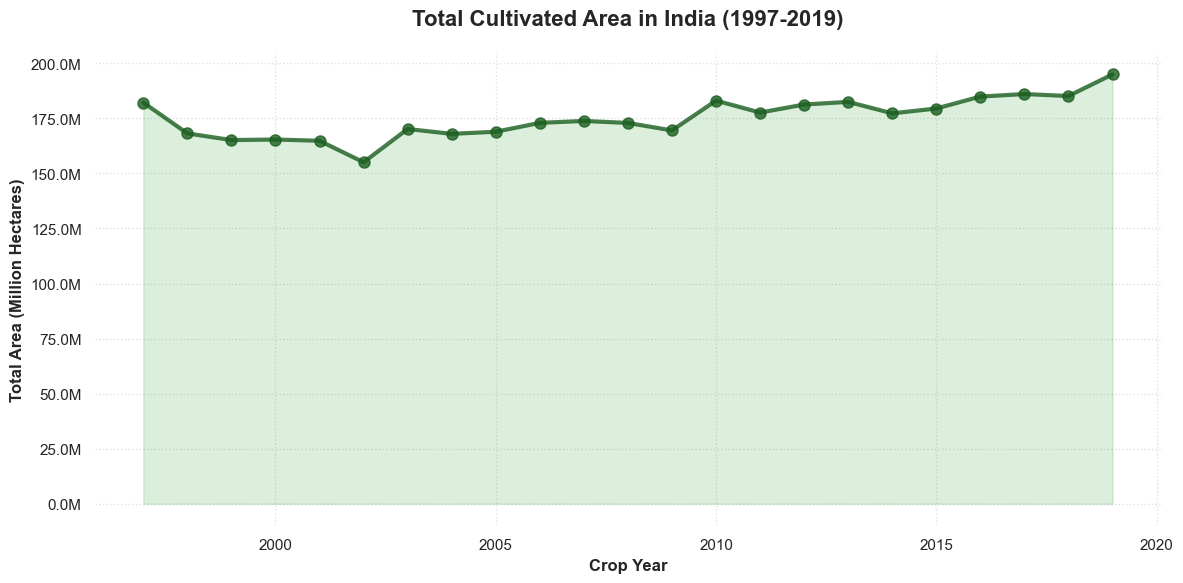

In [6]:
yearly_area = df[df['crop_year'] < 2020].groupby('crop_year')['area'].sum()

plt.figure(figsize=(12, 6))
ax = plt.gca()

# Plot with a rich green color and smooth line
plt.plot(yearly_area.index, yearly_area.values, marker='o', markersize=8, 
         linestyle='-', color='#1b5e20', linewidth=3, alpha=0.8, label='Cultivated Area')

# Fill area under the line for a modern look
plt.fill_between(yearly_area.index, yearly_area.values, color='#4caf50', alpha=0.2)

plt.title('Total Cultivated Area in India (1997-2019)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Crop Year', fontsize=12, fontweight='semibold')
plt.ylabel('Total Area (Million Hectares)', fontsize=12, fontweight='semibold')

# Format Y-axis to show Million instead of scientific notation
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.grid(True, linestyle=':', alpha=0.6)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 2. Seasons

Which season has the most production? I'll use a bar chart here because it's easier to compare values than a pie chart.

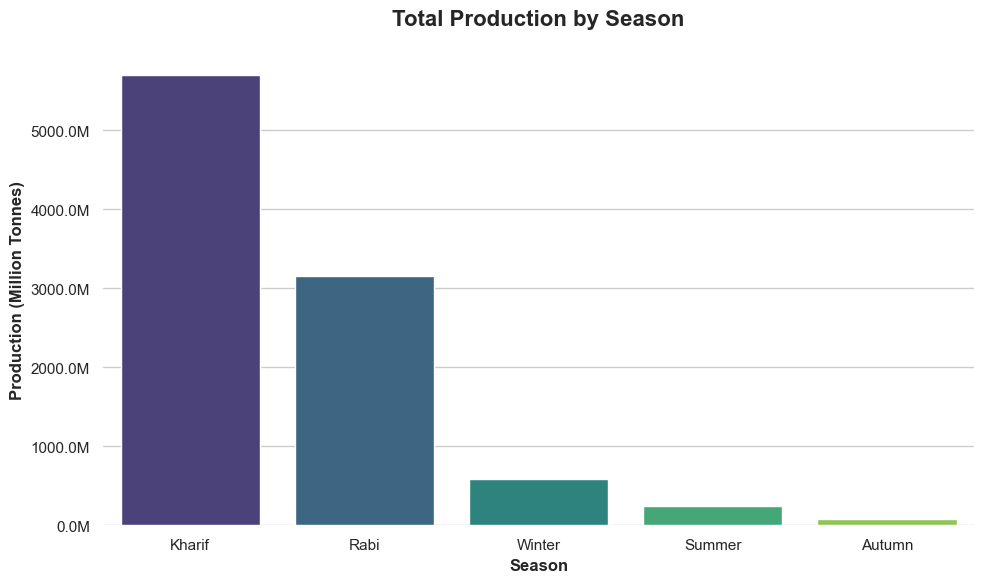

In [11]:
# Excluding 'Whole Year' and 'Coconut' (due to unit mismatch) for fair comparison
season_prod = df[(df['season'] != 'Whole Year') & (df['crop'] != 'Coconut ')].groupby('season')['production'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(x=season_prod.index, y=season_prod.values, hue=season_prod.index, palette='viridis', legend=False)

plt.title('Total Production by Season (Tonnes-based Crops)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Season', fontsize=12, fontweight='semibold')
plt.ylabel('Production (Million Tonnes)', fontsize=12, fontweight='semibold')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 3. Best Crops

I'll look at the top 10 crops by total production. This helps identify the major food sources.

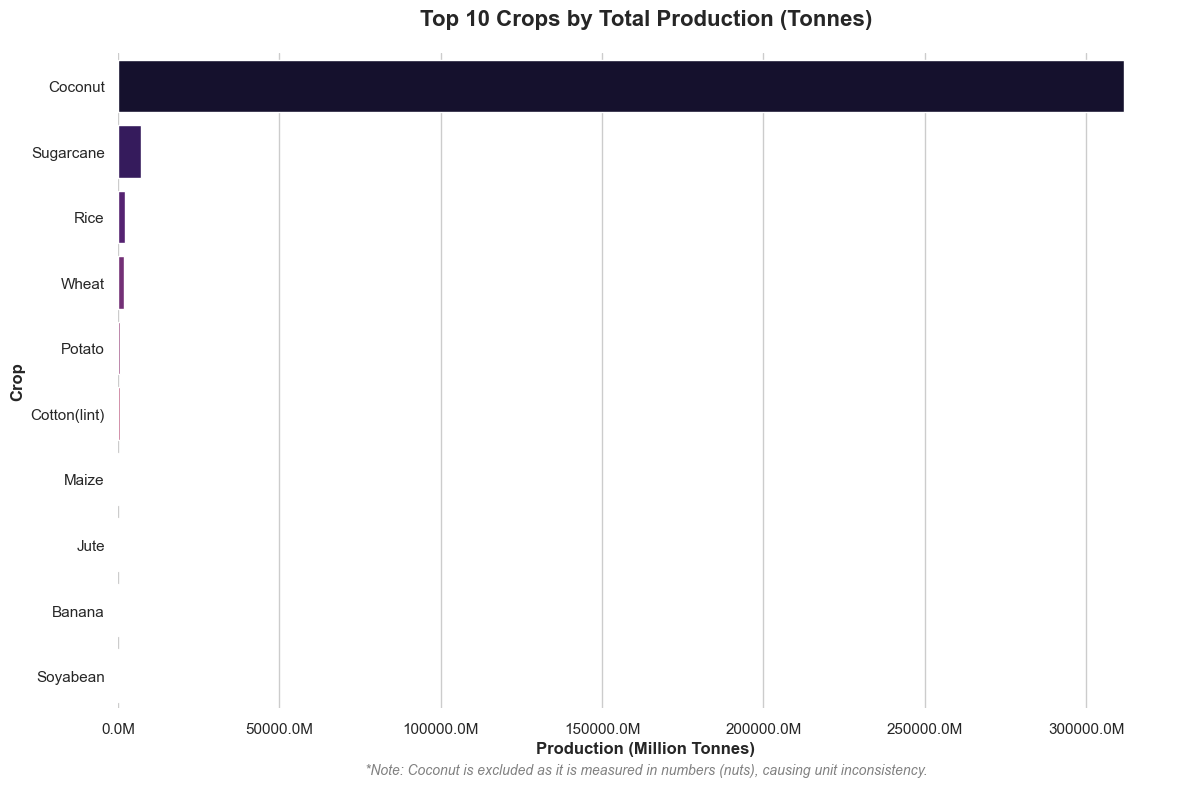

In [13]:
# Excluding 'Coconut' to show top crops measured in Tonnes
top_crops = df[df['crop'] != 'Coconut '].groupby('crop')['production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = plt.gca()

sns.barplot(x=top_crops.values, y=top_crops.index, hue=top_crops.index, palette='magma', legend=False)

plt.title('Top 10 Crops by Total Production (Tonnes)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Production (Million Tonnes)', fontsize=12, fontweight='semibold')
plt.ylabel('Crop', fontsize=12, fontweight='semibold')

# Format X-axis to show Million Tonnes
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.annotate('*Note: Coconut is excluded as it is measured in numbers (nuts), causing unit inconsistency.', 
             xy=(0.5, -0.1), xycoords='axes fraction', ha='center', 
             fontsize=10, fontstyle='italic', color='gray')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Best States by Yield

Now let's see which states have the highest average yield (efficiency).

/var/folders/rb/1t4bf5n12ygczx24mdpy0tc80000gq/T/ipykernel_31843/2548729752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')


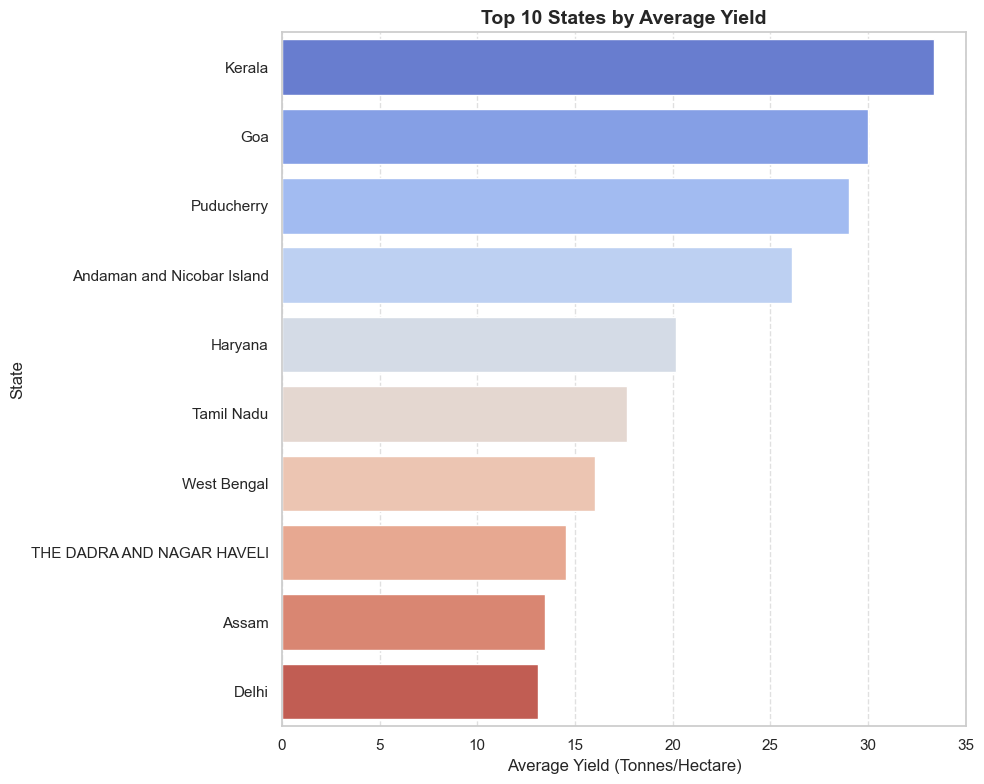

In [5]:
top_states = df.groupby('state')['yield'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_states.values, y=top_states.index, palette='coolwarm')
plt.title('Top 10 States by Average Yield', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield (Tonnes/Hectare)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()